<a href="https://colab.research.google.com/github/ngouanfouo/Grover_Algorithm/blob/main/Ansaetze_and_variational_forms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ansaetze and variational forms

At the heart of all variational algorithms lies the key idea of analyzing the differences between states, which are conveniently related through some well-behaved mapping (for example, continuous, differentiable) from a set of parameters or variables — hence the name.

First, we'll explore how to construct parameterized circuits by hand. We'll use these circuits to define a variational form that represents a collection of parameterized states for our variational algorithm to explore. Then, we'll construct our ansatz by applying this variational form to our reference state.

We'll also explore how to trade off speed versus accuracy while exploring this search space

In [ ]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00


## Parameterized Quantum Circuits

Variational algorithms operate by exploring and comparing a range of quantum states
∣
ψ
(
θ
⃗
)
⟩
∣ψ(
θ
 )⟩, which depend on a finite set of
k
k parameters
θ
⃗
=
(
θ
0
,
…
,
θ
k
−
1
)
θ
 =(θ
0
 ,…,θ
k−1
 ). These states can be prepared using a parametrized quantum circuit, where gates are defined with tunable parameters. It is possible to create this parametrized circuit without binding specific angles yet:

In [ ]:
from qiskit.circuit import QuantumCircuit,Parameter

In [ ]:
theta=Parameter("θ")

In [ ]:
qc=QuantumCircuit(3)
qc.rx(theta,0)
qc.cx(0,1)
qc.x(2)

In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=60253d8eb435878de6fcdf0853a44b0cd3c248c92530458ebc3d836e298dd7c5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


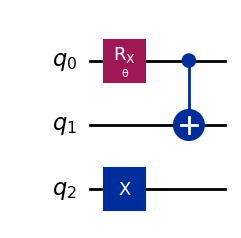

In [ ]:
qc.draw("mpl")

In [ ]:
from math import pi

angle_list = [pi / 3, pi / 2]
circuits=[qc.assign_parameters({theta:angle}) for angle in angle_list]


In [ ]:
from qiskit.circuit.library import NLocal,CCXGate,CRZGate,RXGate
from qiskit.circuit import Parameter

In [ ]:
theta=Parameter("θ")

In [ ]:
ansatz=NLocal(
   num_qubits=5,
   rotation_blocks=[RXGate(theta),CRZGate(theta)],entanglement_blocks=CCXGate(),
   entanglement=[[0,1,2],[0,2,3],[4,2,1],[3,1,0]],
   reps=2,
   insert_barriers=True,
)

/tmp/ipykernel_4391/3949506711.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.n_local.NLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. This applies to NLocal subclasses too. Use the corresponding function from the module qiskit.circuit.library.n_local instead.
  ansatz=NLocal(


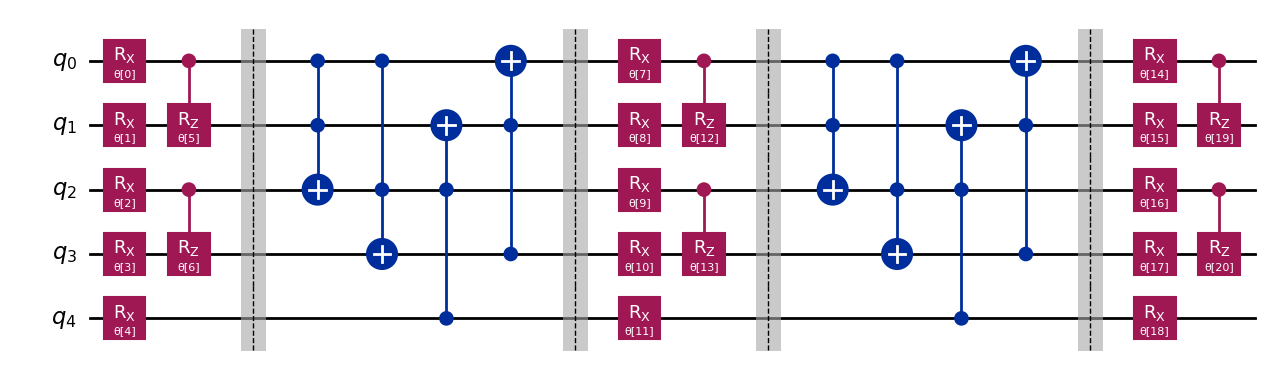

In [ ]:
ansatz.decompose().draw("mpl")

In [ ]:
from qiskit.circuit.library import TwoLocal

In [ ]:
ansatz=TwoLocal(
    num_qubits=5,
    rotation_blocks=["rx","rz"],
    entanglement_blocks="cx",
    entanglement="linear",
    reps=2,
    insert_barriers=True,
)

/tmp/ipykernel_4391/1597313305.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz=TwoLocal(


In [ ]:
from qiskit.circuit.library import efficient_su2

In [ ]:
ansatz=efficient_su2(4,su2_gates=["rx","y"],entanglement="linear",reps=1)

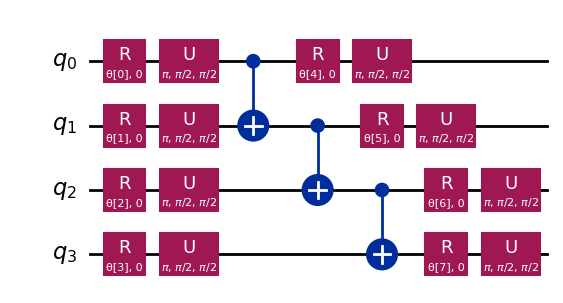

In [ ]:
ansatz.decompose().draw("mpl")

In [ ]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw

In [ ]:
n=4
G=rx.PyGraph()
G.add_nodes_from(range(n))

edges = [(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (2, 3, 1.0)]
G.add_edges_from(edges)

EdgeIndices[0, 1, 2, 3, 4]

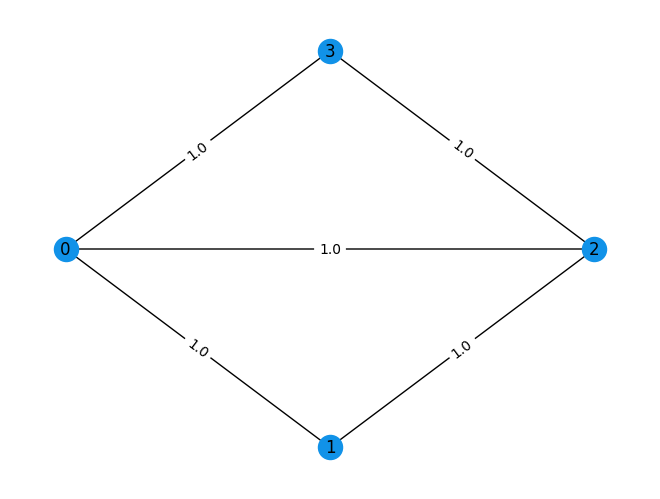

In [ ]:

mpl_draw(
    G, pos=rx.shell_layout(G), with_labels=True, edge_labels=str, node_color="#1192E8"
)

In [ ]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

In [ ]:
#problem to the Halmiltonian operator
hamiltonian = SparsePauliOp.from_list(
    [("ZZII", 1), ("IZZI", 1), ("ZIIZ", 1), ("IZIZ", 1), ("IIZZ", 1)]
)

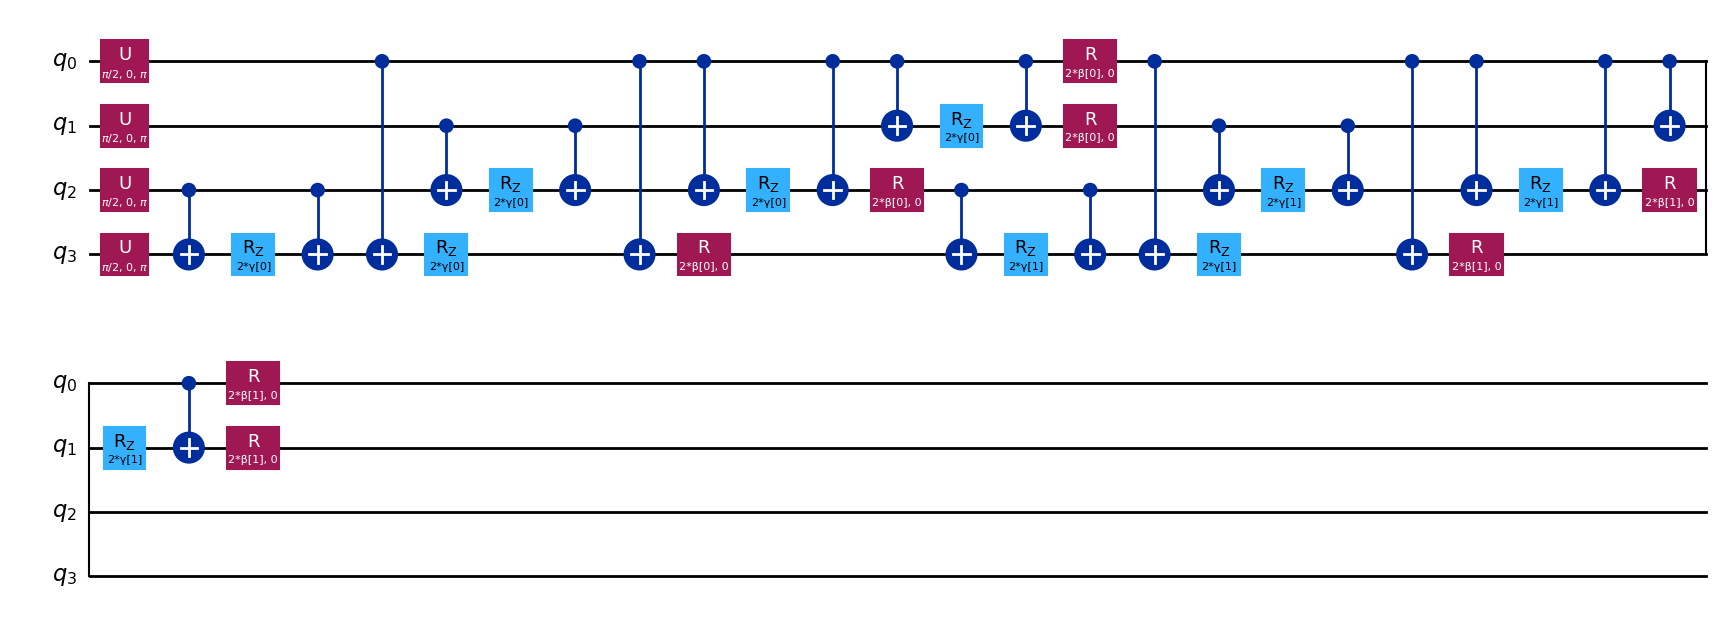

In [ ]:
# QAOA ansatz circuit
ansatz = QAOAAnsatz(hamiltonian, reps=2)
# Draw
ansatz.decompose(reps=3).draw("mpl")

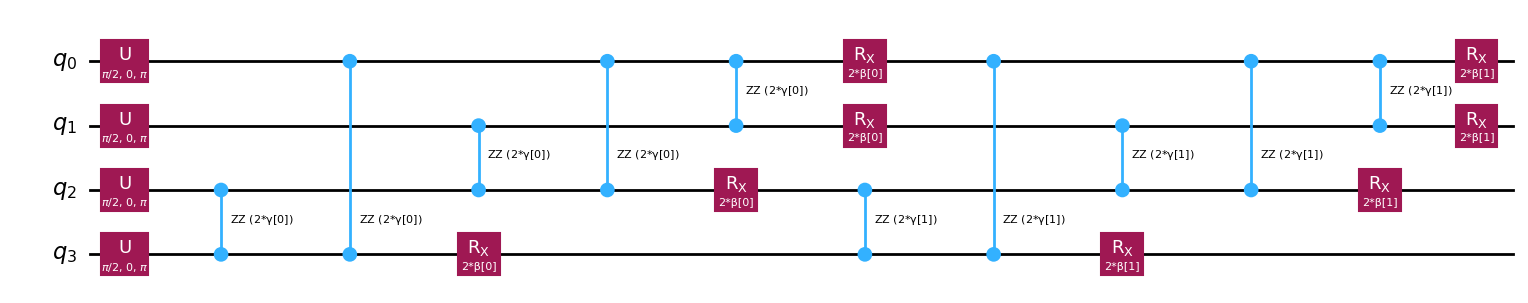

In [ ]:
ansatz.decompose(reps=2).draw("mpl")

/tmp/ipykernel_4391/2468103719.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  variation_form = TwoLocal(2, ["ry", "rz"], "cz", reps=2)


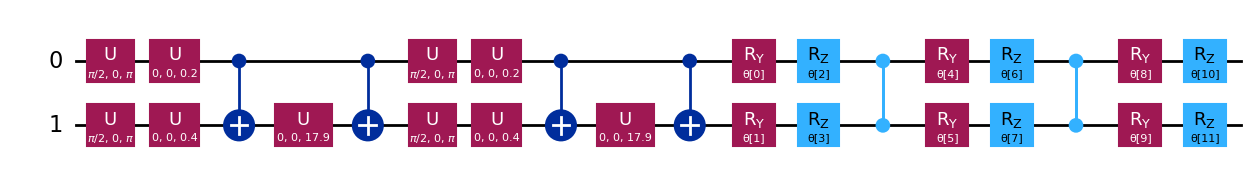

In [ ]:
from qiskit.circuit.library import zz_feature_map,TwoLocal
data=[0.1,0.2]

zz_feature_map_reference = zz_feature_map(feature_dimension=2, reps=2)
zz_feature_map_reference = zz_feature_map_reference.assign_parameters(data)

variation_form = TwoLocal(2, ["ry", "rz"], "cz", reps=2)
vqc_ansatz = zz_feature_map_reference.compose(variation_form)
vqc_ansatz.decompose().draw("mpl")

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
